# Lab 8 Tasks - Solution

In this notebook we will use regression techniques to analyse a subset of the [2019 World Happiness Index Report](https://worldhappiness.report/) dataset. In this dataset each row represents a country, with the following features:

- *country*: name of the country for each row
- *gdp*: real GDP per capita
- *social_support*: amount of social support that is present in a country
- *health*: healthy life expectancy,
- *freedom*: freedom to make life choices 
- *generosity*: leve of generosity of citizens
- *corruption*: perceptions of corruption in a country

## Task 1

Download the file happiness2019.csv from BrightSpace, and load the data into a Pandas DataFrame. Use the Country column as the index. Print the first five rows.


In [1]:
import pandas as pd
# Pandas can download the data directly from the URL
df = pd.read_csv("happiness2019.csv", index_col="country")
df.head(5)

,gdp,social_support,health,freedom,generosity,corruption
country,,,,,,
Afghanistan,0.350,0.517,0.361,0.000,0.158,0.025
Albania,0.947,0.848,0.874,0.383,0.178,0.027
Algeria,1.002,1.160,0.785,0.086,0.073,0.114
Argentina,1.092,1.432,0.881,0.471,0.066,0.050
Armenia,0.850,1.055,0.815,0.283,0.095,0.064


## Task 2 

Calculate basic summary statistics for the data. 

In [2]:
df.describe()

,gdp,social_support,health,freedom,generosity,corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


Generate a boxplot of the measures in the dataset. 

Do you see any **outliers** for any of the measures?

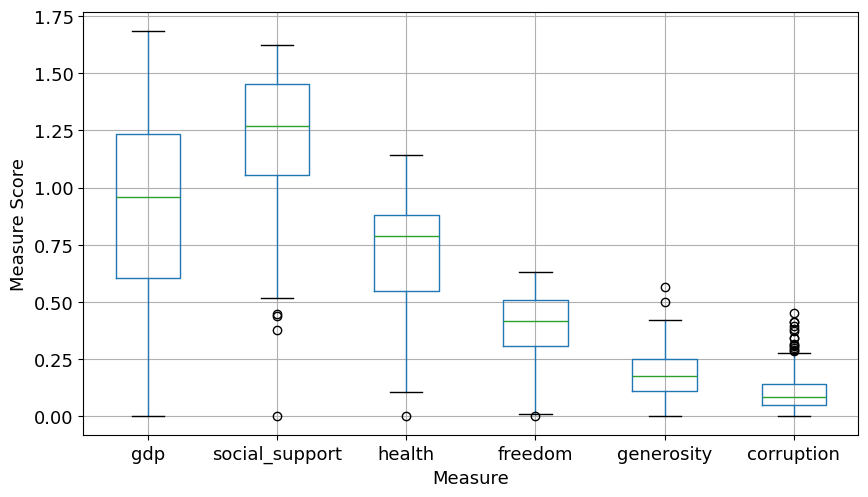

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
# generate the box plot
df.boxplot(figsize=(10, 5.5), fontsize=13)
plt.xlabel("Measure", fontsize=13)
plt.ylabel("Measure Score", fontsize=13);
plt.show()

In the above we can spot potential outliers that appear above or below the T-bars of each boxplot (i.e. above/below the maximum/minimum limits of the boxplot). For instance, we see some lower outliers for the measures *social_support*, *health* and *freedom*, while we see some upper outliers for *generosity* and *corruption*.

## Task 3

Calculate the correlations between the different variables in the data. 

Which pair of variables are: (i) the most highly correlated; (ii) the least correlated?

In [4]:
# calculate the pairwise correlations
df_c = df.corr()
df_c

,gdp,social_support,health,freedom,generosity,corruption
gdp,1.000000,0.754906,0.835462,0.379079,-0.079662,0.298920
social_support,0.754906,1.000000,0.719009,0.447333,-0.048126,0.181899
health,0.835462,0.719009,1.000000,0.390395,-0.029511,0.295283
freedom,0.379079,0.447333,0.390395,1.000000,0.269742,0.438843
generosity,-0.079662,-0.048126,-0.029511,0.269742,1.000000,0.326538
corruption,0.298920,0.181899,0.295283,0.438843,0.326538,1.000000


In [5]:
# we could turn this into a sorted DataFrame to show us a ranking for the pairs of variables
# with the highest and lowest correlation
from itertools import combinations
rows = []
for v1, v2 in combinations(df_c.columns, 2):
    rows.append({"Variable 1": v1, "Variable 2": v2, "Correlation": df_c[v1][v2]})
# show the ranked list
pd.DataFrame(rows).sort_values(by="Correlation", ascending=False)

,Variable 1,Variable 2,Correlation
1,gdp,health,0.835462
0,gdp,social_support,0.754906
5,social_support,health,0.719009
6,social_support,freedom,0.447333
13,freedom,corruption,0.438843
9,health,freedom,0.390395
2,gdp,freedom,0.379079
14,generosity,corruption,0.326538
4,gdp,corruption,0.298920
11,health,corruption,0.295283


## Task 4

Apply a **simple linear regression** to learn (fit) the model, where *gdp* is the independent variable and *health* is the target variable that we would like to predict. Produce a plot of the regression line.

Coefficient (slope): 0.5078
Intercept: 0.2656


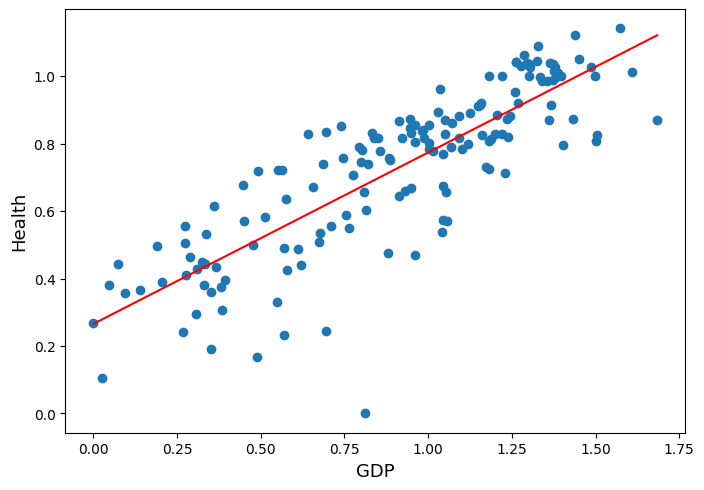

In [6]:
# Get the columns
x = df[["gdp"]].values
y = df[["health"]].values

# Now build the regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x, y)

# Print the coefficients of the model
print("Coefficient (slope): %.4f" % model.coef_[0][0])
print("Intercept: %.4f" % model.intercept_[0])

# plot the data
plt.figure(figsize=(8, 5.5))
plt.scatter(x, y)

# plot the regression line
m = model.coef_[0]
b = model.intercept_
plt.plot([min(x), max(x)], [b, m*max(x) + b], 'r')

# Add labels and show the plot
plt.xlabel('GDP', fontsize=13)
plt.ylabel('Health', fontsize=13);
plt.show()

## Task 5

Repeat the process from Task 4, but this time use *generosity* as the **target** variable. What does a comparison of the two regression lines indicate?

Coefficient (slope): -0.0190
Intercept: 0.2021


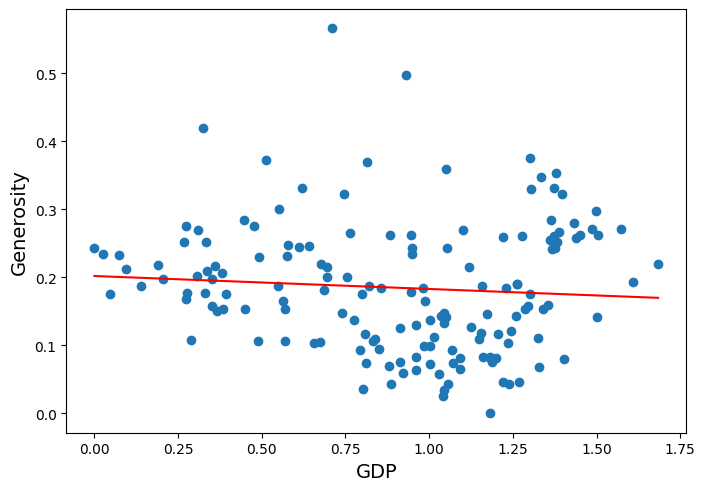

In [7]:
# Get the columns
x = df[["gdp"]].values
y = df[["generosity"]].values
# Now build the regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x, y)
print("Coefficient (slope): %.4f" % model.coef_[0][0])
print("Intercept: %.4f" % model.intercept_[0])
# plot the data
plt.figure(figsize=(8, 5.5))
plt.scatter(x, y)
# plot the regression line
m = model.coef_[0]
b = model.intercept_
plt.plot([min(x), max(x)], [b, m*max(x) + b], 'r')
plt.xlabel('GDP', fontsize=14)
plt.ylabel('Generosity', fontsize=14);
plt.show()

There appears to be a strong correlation between GDP per capita and healthy life expectancy, for far less correlation between GDP per capita and generosity (i.e. level of charitable donations).